In [1]:
import time
start_time = time.time()
import os, sys, pickle, datetime, re, io, pytz
import numpy  as np
import matplotlib.pyplot as plt
from   matplotlib.dates import DateFormatter
import pandas as pd
from IPython.display import HTML
import base64
from io import BytesIO
from   importlib import reload
local_directory = './'
sys.path.append(local_directory)
#import daily_report_utils
from dto_classes import dto_ness_parquet
from scipy.interpolate import interp1d
from scipy.stats.mstats import winsorize  
import pytz
import re
import math
import traceback
from scipy.linalg import cholesky
from pathlib import Path
from scipy.interpolate import interp1d, UnivariateSpline
import soh_estimator
import ecm_parameter_estimator
import spkf
import awtls
import ness_utils 

In [2]:
pack_voltage         = 'lv'
pack_chg_current     = 'ic'
pack_dischg_current  = 'id'
pack_current         =  'Ip'
pack_temperature     = 'tmp'
pack_SOC             = 'soc'
timestamp            = 'ts'
#str_volt_columns = list(col_name for col_name in data_df.columns if 'strv_' in col_name)
str_volt_columns     = ['strv_1',  'strv_2',  'strv_3',  'strv_4',  'strv_5',  'strv_6', 'strv_7', 'strv_8', 'strv_9', 'strv_10',
                        'strv_11', 'strv_12', 'strv_13', 'strv_14', 'strv_15', 'strv_16']
estimated_SOC        = 'Estimated_SOC'
selected_SOC         = pack_SOC
load_status          = 'load_status'
#---------------------------------------------------#

In [3]:
indian_time      = pytz.timezone('Asia/Kolkata')
time_ticks       = DateFormatter("%H:%M", tz = indian_time)
indian_timestamp = 'indian_time'

In [4]:
sigma_z =0.01 
sigma_x2 = 2*sigma_z**2  # vara z2-z1 (soc difference)
sigma_y2 = 1e-6  

In [5]:
charging_load_status =4
discharging_load_status =3
idle_state = 0

def get_load_status(current):
    ## this is for nan
    if pd.isna(current):
        return np.nan
    ## charging: 4
    elif current > 10:
        return charging_load_status
    ## discharging: 3
    elif current < -10:
        return discharging_load_status
    # Rest
    else:
        return idle_state

In [6]:
def add_time_columns(data_df):
    data_df.sort_values(by     = [timestamp], inplace = True, ignore_index = True)
    data_df['utc_time']        = pd.to_datetime(data_df[timestamp], unit= 'ms', utc=True)
    data_df['indian_time']     = data_df['utc_time'].dt.tz_convert(indian_time)
    data_df['diff_time_secs']  = ness_utils.get_diff_time(data_df['utc_time'])
    date_string                = data_df['utc_time'].iloc[-1].date().strftime("%d-%b-%Y")
    return data_df, date_string

In [7]:
def get_state_session_id(veh_batt_df):
    diff_state           = veh_batt_df[load_status] != veh_batt_df[load_status].shift(1)
    #veh_batt_df['session_id'] = (diff_state).cumsum()
    gt_5min = veh_batt_df[indian_timestamp].diff() > pd.Timedelta("5min")
    veh_batt_df['session_id'] = (diff_state | gt_5min).cumsum()
    return  veh_batt_df

In [8]:
#-------------------------soh estimation parameters..................................................
Charging_SOH = False
# if Charging_SOH:
#     pack_current =pack_chg_current
#     selected_state = 1 #charging
# else:
#     pack_current =pack_dischg_current
#     selected_state =2  #discharging
# #--------------------------------------------------------------------------------------------------------------------------
# Referance capacity is 90% 120 Ah capacity 
soc_voltage_range = {'voltage_lower_range_mV':3200,'voltage_upper_range_mV':3400,'soc_lower':45,'soc_upper':65,'reference_capacity_mAh':120000*0.90}
soh_bins = [0,0.85, 0.90, 0.95, 1.5]  
time_difference_limit_sec =300

In [9]:
soc_ah_kwh_rage_dict = {'0-20':[],'20-40':[],'40-60':[],'60-80':[],'80-100':[]}

# Nominal Capacity 

In [10]:
def get_Ah_kWh_hrs_maxA(curr_mA, pack_V_mV, diff_time_secs):
    calc_vals_dict = {}
    calc_vals_dict['op_time']     = round(np.sum(diff_time_secs)/3600., 2)
    if len(curr_mA) > 0:
        calc_vals_dict['max_curr_A']  = round(np.max(curr_mA)/1000., 2)
        calc_vals_dict['mean_curr_A'] = round(np.mean(curr_mA)/1000., 2)
        calc_vals_dict['cap_Ah']      = round(np.nansum(curr_mA * diff_time_secs)/3600./1000., 2)
        calc_vals_dict['energy_kWh']  = round(np.sum(curr_mA * diff_time_secs * pack_V_mV)/3600./1000./1000./1000., 2)
    else:
        calc_vals_dict['max_curr_A']  = None
        calc_vals_dict['mean_curr_A'] = None
        calc_vals_dict['cap_Ah']      = None
        calc_vals_dict['energy_kWh']  = None
        
    return calc_vals_dict


In [11]:
## Energy 
def get_percentage_gap(energy_series,ref_energy):
    mean_energy = np.mean(winsorize(energy_series, limits = [0.25, 0.25]))
    return 100*(energy_series - mean_energy) / (ref_energy)

def get_stringwise_energy(summary_dict, df):
    #selected_str_volt_columns    = list(set(string_voltage_columns).intersection(set(df.columns)))
    selected_str_volt_columns = [col for col in str_volt_columns if col in df.columns]
    chg_df               = df[df[load_status] == charging_load_status]
    chg_string_power     = chg_df[selected_str_volt_columns].multiply(chg_df[pack_chg_current].abs(), axis = 0)
   
    diff_time_secs       = chg_df['diff_time_secs'].copy(deep= True)
    diff_time_secs.loc[diff_time_secs >= time_difference_limit_sec] = 1.
    chg_string_energy    = chg_string_power.multiply(diff_time_secs, axis = 0)
    total_chg_string_energy    = chg_string_energy.sum(axis= 0)/3600./1000./1000
    dischg_df    = df[df[load_status] == discharging_load_status]
    dischg_string_power  = dischg_df[selected_str_volt_columns].multiply(dischg_df[pack_dischg_current].abs(), axis = 0)
    diff_time_secs       = dischg_df['diff_time_secs'].copy(deep= True)
    diff_time_secs.loc[diff_time_secs >= time_difference_limit_sec] = 1.
    dischg_string_energy = dischg_string_power.multiply(diff_time_secs, axis = 0)
    total_dischg_string_energy = dischg_string_energy.sum(axis= 0)/3600./1000./1000
    string_Ergy_df = pd.DataFrame({'string_num'    : pd.Series(selected_str_volt_columns), \
                                   'chg_ergy_Wh'   : pd.Series(total_chg_string_energy.to_list()),           \
                                   'dischg_ergy_Wh': pd.Series(total_dischg_string_energy.to_list())})
    
    if not string_Ergy_df.empty:
        #string_Ergy_df.fillna(0,inplace=True)
        if string_Ergy_df['chg_ergy_Wh'].all()   == 0:
            string_Ergy_df['chg_ergy_%gap']      = pd.Series([0.] * len(string_Ergy_df['chg_ergy_Wh'].values))
        else:
            string_Ergy_df['chg_ergy_%gap']      = pd.Series(get_percentage_gap(string_Ergy_df['chg_ergy_Wh'],
                                                                                summary_dict['str_ref_Ergy_Wh']).to_list())
        if string_Ergy_df['dischg_ergy_Wh'].all() == 0:
            string_Ergy_df['dischg_ergy_%gap']   = pd.Series([0.] * len(string_Ergy_df['dischg_ergy_Wh'].values))
        else:
            string_Ergy_df['dischg_ergy_%gap']   = pd.Series(get_percentage_gap(string_Ergy_df['dischg_ergy_Wh'],
                                                                                 summary_dict['str_ref_Ergy_Wh']).to_list())

        string_Ergy_df['abs_%ergy_gap']          = np.abs(string_Ergy_df['chg_ergy_%gap']) + np.abs(string_Ergy_df['dischg_ergy_%gap'])
        string_Ergy_df['%ergy_gap']              = string_Ergy_df['chg_ergy_%gap'] + string_Ergy_df['dischg_ergy_%gap']

        string_Ergy_df                           = string_Ergy_df[~(string_Ergy_df['abs_%ergy_gap'].isnull())]
        max_Erggap_string                        = string_Ergy_df.loc[string_Ergy_df['abs_%ergy_gap'].idxmax()]

        summary_dict['max_abs_%Ergy_gap']        =  max_Erggap_string['abs_%ergy_gap']
        summary_dict['max_abs_%Ergy_gap_string'] =  max_Erggap_string['string_num']
        summary_dict['max_chg_ergy_%_gap']       =  max_Erggap_string['chg_ergy_%gap']
        summary_dict['max_dchg_ergy_%_gap']      =  max_Erggap_string['dischg_ergy_%gap']
    return summary_dict,string_Ergy_df

In [12]:
import numpy as np
import re

def compute_max_imbalance_20_80(batt_df):
    """
    Returns:
        max_imbalance, min_column_num, max_column_num
    """
    available_str_cols = batt_df.columns.intersection(str_volt_columns)
    # Filter SOC range
    soc_df = batt_df[batt_df['soc'].between(20, 80)]
    if soc_df.empty:
        return np.nan, np.nan, np.nan
    # Row-wise max-min difference
    row_max = soc_df[available_str_cols].max(axis=1)
    row_min = soc_df[available_str_cols].min(axis=1)
    diff = row_max - row_min
    # Index of maximum imbalance
    idx = diff.idxmax()
    max_imbalance = diff.loc[idx]
    # Column names of max & min string at that index
    max_col = soc_df.loc[idx, available_str_cols].idxmax()
    min_col = soc_df.loc[idx, available_str_cols].idxmin()

    # Extract numeric part (e.g., strv_12 → 12)
    max_column_num = int(re.search(r'\d+', max_col).group())
    min_column_num = int(re.search(r'\d+', min_col).group())

    return max_imbalance, min_column_num, max_column_num


In [13]:
def get_model_path(battery_id, bat_meta_data_dict, base_data_dir):
    from pathlib import Path
    import json
    if battery_id not in bat_meta_data_dict:
        raise KeyError(f"Battery ID not found: {battery_id}")
    meta = bat_meta_data_dict[battery_id]
    chemistry = meta["chemistry_type"].upper()
    ref_capacity = meta["reference_capacity"]
    if chemistry not in ("LFP", "NMC"):
        raise ValueError(f"Unsupported chemistry: {chemistry}")
    base_data_dir = Path(base_data_dir)
    default_json = base_data_dir / chemistry / "default" / "old_ness_param.json"
    batt_dir = base_data_dir / chemistry / battery_id
    batt_dir.mkdir(parents=True, exist_ok=True)
    batt_json = batt_dir / "new_ness_param.json"
    if not batt_json.exists():
        with open(default_json) as f:
            model_data = json.load(f)
        model_data["QParam"] = ref_capacity
        with open(batt_json, "w") as f:
            json.dump(model_data, f, indent=4)
    return batt_json


def update_qparam(json_path, qparam):
    import json
    with open(json_path, "r") as f:
        data = json.load(f)
    data["QParam"] = qparam
    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)



In [14]:
batt_meta_data = pd.read_csv("E:/ness_performance_evaluation/data/input/ness_details.csv")
batt_meta_data_df = batt_meta_data.drop_duplicates("battery_name", keep="first")
bat_meta_data_dict = batt_meta_data_df.set_index("battery_name")[["chemistry_type", "reference_capacity",'pack_capacity_kwh',
                                                                  'number_of_strings',"nominal_voltage"]].to_dict("index")

In [15]:
indian_timestamp

'indian_time'

In [16]:
selected_SOC

'soc'

In [17]:
def get_sessions_summary(batt_df,things_board_id):
    sessions = []
    for sid, g in batt_df.groupby("session_id"):
        state = g[load_status].iloc[0]
        # ignore idle sessions
        if state == 0:
            continue
        start_time = g[indian_timestamp].iloc[0]
        end_time = g[indian_timestamp].iloc[-1]
        delta_time = (end_time - start_time).total_seconds()/3600
        start_soc = g[selected_SOC].iloc[0]
        end_soc = g[selected_SOC].iloc[-1]
        delta_soc = end_soc - start_soc
        if abs(delta_soc) < 5:
            continue
        avg_current_A = g[pack_current].mean()/1000
        avg_power_W = (g[pack_voltage] * g[pack_current]).mean() / 1e6
        inst_current = g[pack_current].iloc[-1]/1000
        inst_power = g[pack_voltage].iloc[-1] * g[pack_current].iloc[-1] / 1e6
        if state == 3:
            time_remains_hr = start_soc * delta_time / abs(delta_soc)
        else:
            time_remains_hr = (100 - start_soc) * delta_time / abs(delta_soc)
        soc_over_current    = start_soc / avg_current_A if avg_current_A > 0 else np.nan
        # session_rate = observed hrs per 1% SOC change in this session.
        # time_remaining = initial_soc_remaining * session_rate (exact formula).
        # Including this as a feature lets the model handle all sessions —
        # fast, slow, and outlier — without needing hard thresholds.
        session_rate        = delta_time / abs(delta_soc) if abs(delta_soc) > 0 else np.nan
        sessions.append(
            {
            'id': things_board_id,
            "session_id": sid,
            "state": state,
            "start_time": start_time,
            "end_time": end_time,
            "start_soc": start_soc,
            "end_soc": end_soc,
            "delta_soc": delta_soc,
            "delta_time_hr": delta_time,
            "time_remaining_hr": time_remains_hr,
            "session_avg_current": avg_current_A,
            "session_avg_power": avg_power_W,
            "soc_over_current": soc_over_current,
            "session_rate": session_rate,
            #"inst_current": inst_current,
            #"inst_power": inst_power,
            "initial_soc": start_soc
            }
        )
    return sessions


In [34]:
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "E:/ness_performance_evaluation/data/output"
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "E:/ness_performance_evaluation/data/output"

def generate_current_plot(batt_df, things_board_id):

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Primary axis → Current
    ax1.plot(batt_df[indian_timestamp], batt_df['ic'] - batt_df['id'], label="Current")
    ax1.set_xlabel("Timestamp")
    ax1.set_ylabel("Pack Current (A)")

    # Secondary axis → SOC
    ax2 = ax1.twinx()
    ax2.plot(batt_df[indian_timestamp], batt_df[pack_SOC], linestyle='--', label="SOC")
    ax2.set_ylabel("Pack SOC (%)")

    plt.title(f"Pack Current vs Time - {things_board_id}")
    plt.xticks(rotation=45)
    fig.tight_layout()

    file_path = os.path.join(OUTPUT_DIR, f"{things_board_id}_current_plot.png")
    plt.savefig(file_path)

    plt.close()

In [37]:
import os
import plotly.graph_objects as go

OUTPUT_DIR = "E:/ness_performance_evaluation/data/output"

def generate_current_plot(batt_df, things_board_id):

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    fig = go.Figure()

    # Current trace
    fig.add_trace(
        go.Scatter(
            x=batt_df[indian_timestamp],
            y=batt_df['ic'] - batt_df['id'],
            name="Pack Current",
            mode='lines',
            yaxis="y1"
        )
    )

    # SOC trace (secondary axis)
    fig.add_trace(
        go.Scatter(
            x=batt_df[indian_timestamp],
            y=batt_df[pack_SOC],
            name="SOC",
            mode='lines',
            yaxis="y2"
        )
    )

    fig.update_layout(
        title=f"Pack Current vs Time - {things_board_id}",
        xaxis=dict(title="Timestamp"),
        yaxis=dict(title="Current (A)"),
        yaxis2=dict(
            title="SOC (%)",
            overlaying="y",
            side="right"
        ),
        hovermode="x unified"
    )

    file_path = os.path.join(OUTPUT_DIR, f"{things_board_id}_current_plot.html")

    fig.write_html(file_path)

# Getting Process Loop Complete 

In [19]:
import pandas as pd
import numpy as np
import re
BASE_DIR  = "E:/ness_performance_evaluation/data/input"
#OUTPUT_JSON = "E:/ness_performance_evaluation/data/new_ness_param.json"
def process_single_pack(things_board_id,file_path):
    meta = bat_meta_data_dict.get(things_board_id, {})
    Q_nom = meta.get("reference_capacity", 100)
    string_ref_energy =  meta.get("pack_capacity_kwh", 4.5)*1000/meta.get("number_of_strings", 16)
    Nominal_Voltage = meta.get("nominal_voltage",51.2)
    try:
        df = pd.read_parquet(file_path)
        df = dto_ness_parquet(df).df

        df,_ = add_time_columns(df)
        df['month'] = pd.to_datetime(df['indian_time']).dt.to_period('M').astype(str)
        month = df['month'].unique()
        available_str_cols = df.columns.intersection(str_volt_columns)
        batt_df = df[
            (df[available_str_cols].max(axis=1) < 4000) &
            (df[available_str_cols].min(axis=1) > 2500)
        ]
        #print (batt_df)
        # creating two additional columns: pack_current and load_status ##########
        batt_df[pack_current] = batt_df[pack_chg_current]-batt_df[pack_dischg_current]
        batt_df[load_status] = batt_df[pack_current].astype(float).apply(get_load_status)
        batt_df[pack_current] =batt_df[pack_current].abs()
        #---------------------------------------------------------------------------- 
        #batt_df = get_state(batt_df)
        batt_df, _ = add_time_columns(batt_df)
        batt_df =  get_state_session_id(batt_df)
        #plot and  current vs time stamp
        generate_current_plot(batt_df,things_board_id)
        max_temp = batt_df[pack_temperature].max()
        avg_temp = batt_df[pack_temperature].mean()
        sessions_summary = get_sessions_summary(batt_df,things_board_id)
    except Exception:
        print ('Error some where')
    return sessions_summary

In [20]:
def process_data(required_dir, things_board_ids):
    all_sessions = []
    for things_board_id in things_board_ids:
        file_path = f"{required_dir}/{things_board_id}.parquet"
        sessions = process_single_pack(things_board_id, file_path)
        if sessions:
            all_sessions.extend(sessions)
    performance_df = pd.DataFrame(all_sessions)
    return performance_df

# Final Execution Step

In [38]:
#required_dir = '../data/march_data/Mlinda_115/'
required_dir = 'E:/ness_performance_evaluation/data/soh_test_4'
import os # change this to your actual path
things_board_ids =[]
for file in os.listdir(required_dir):
    if file.endswith('.parquet'):
        battery_id = file.replace('.parquet', '')
        things_board_ids.append(battery_id)
print(things_board_ids)
summary_df= process_data(required_dir,things_board_ids)

['SE1100000480']


In [31]:
summary_df.columns

Index(['id', 'session_id', 'state', 'start_time', 'end_time', 'start_soc',
       'end_soc', 'delta_soc', 'delta_time_hr', 'time_remaining_hr',
       'session_avg_current', 'session_avg_power', 'soc_over_current',
       'session_rate', 'initial_soc'],
      dtype='object')

In [39]:
summary_df_discharge = summary_df[summary_df['state']==3]

In [ ]:
summary_df_discharge['']

,id,session_id,state,start_time,end_time,start_soc,end_soc,delta_soc,delta_time_hr,time_remaining_hr,session_avg_current,session_avg_power,soc_over_current,session_rate,initial_soc
1,SE1100000480,61,3,2025-05-08 16:19:27.467000+05:30,2025-05-08 17:00:06.644000+05:30,37.0,22.0,-15.0,0.677549,1.671288,20.181508,1048.227125,1.833362,0.045170,37.0
2,SE1100000480,71,3,2025-05-08 19:03:05.494000+05:30,2025-05-09 03:57:16.745000+05:30,23.0,11.0,-12.0,8.903125,17.064323,1.294202,67.006078,17.771563,0.741927,23.0
6,SE1100000480,675,3,2025-05-09 17:56:23.723000+05:30,2025-05-09 21:53:33.257000+05:30,97.0,0.0,-97.0,3.952648,3.952648,27.409853,1419.466402,3.538873,0.040749,97.0
12,SE1100000480,701,3,2025-05-10 10:53:45.474000+05:30,2025-05-10 11:06:27.176000+05:30,87.0,81.0,-6.0,0.211584,3.067966,25.669280,1342.785846,3.389265,0.035264,87.0
13,SE1100000480,703,3,2025-05-10 11:19:02.934000+05:30,2025-05-10 11:58:40.650000+05:30,83.0,73.0,-10.0,0.660477,5.481956,13.616881,712.522155,6.095375,0.066048,83.0
14,SE1100000480,751,3,2025-05-10 13:05:45.011000+05:30,2025-05-10 13:58:35.286000+05:30,66.0,46.0,-20.0,0.880632,2.906085,20.152205,1049.448594,3.275076,0.044032,66.0
19,SE1100000480,781,3,2025-05-10 18:01:28.768000+05:30,2025-05-10 22:23:31.430000+05:30,98.0,57.0,-41.0,4.367406,10.439166,8.423451,442.330312,11.634187,0.106522,98.0
20,SE1100000480,782,3,2025-05-10 22:29:33.848000+05:30,2025-05-11 04:52:38.538000+05:30,56.0,0.0,-56.0,6.384636,6.384636,9.110365,469.815284,6.146845,0.114011,56.0
25,SE1100000480,2238,3,2025-05-11 16:21:53.896000+05:30,2025-05-11 16:36:38.627000+05:30,100.0,95.0,-5.0,0.245759,4.915172,16.516207,871.308467,6.054659,0.049152,100.0
26,SE1100000480,2250,3,2025-05-11 18:00:18.202000+05:30,2025-05-12 05:19:55.921000+05:30,93.0,0.0,-93.0,11.327144,11.327144,9.307153,484.042892,9.992315,0.121797,93.0


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# delta_time_hr added to both states — directly encodes session scale,
# critical for predicting both short fast and long slow sessions accurately.
# soc_over_current kept for discharging — encodes the physics ratio soc/current.
# Target is log1p-transformed during training so the model learns proportional
# errors across the full range (1–60 hr); predictions are inverse-transformed
# back to hours for MAE/R² reporting.
FEATURES_BY_STATE = {
    4: ['initial_soc', 'session_avg_current', 'session_avg_power', 'delta_time_hr', 'session_rate'],
    3: ['initial_soc', 'session_avg_current', 'session_avg_power', 'soc_over_current', 'delta_time_hr', 'session_rate'],
}
TARGET             = 'time_remaining_hr'
STATE_LABELS       = {4: 'charging', 3: 'discharging'}
MIN_CURRENT_A      = 1.0    # only filter true noise-level sessions
# When RF prediction exceeds this threshold, switch to physics formula
PHYSICS_THRESHOLD  = {4: 12.0, 3: 50.0}   # charging: 12 hr, discharging: 50 hr

# keys: (batt_id, state_val)
rf_models    = {}
rf_scalers   = {}
rf_results   = []
rf_eval_data = {}   # stores test-set y_true / y_pred for Cell 26 plotting

for batt_id, batt_group in summary_df.groupby('id'):
    for state_val, state_name in STATE_LABELS.items():
        features = FEATURES_BY_STATE[state_val]

        df_state = (
            batt_group[batt_group['state'] == state_val][features + [TARGET]]
            .dropna()
            .reset_index(drop=True)
        )

        # Filter 1: remove true noise-level sessions (< 1 A)
        before   = len(df_state)
        df_state = df_state[df_state['session_avg_current'] >= MIN_CURRENT_A].reset_index(drop=True)
        removed  = before - len(df_state)
        if removed:
            print(f"  [{state_name}] removed {removed} low-current session(s) "
                  f"(avg_current < {MIN_CURRENT_A} A) — {len(df_state)} remain")


        if len(df_state) < 5:
            print(f"[{batt_id}][{state_name}] Not enough data ({len(df_state)} rows) — skipping.")
            continue

        X = df_state[features]
        y = df_state[TARGET]

        # Use 80/20 split when >=20 sessions; otherwise train and evaluate on all
        if len(df_state) >= 20:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
            eval_note = ''
        else:
            X_train, X_test, y_train, y_test = X, X, y, y
            eval_note = ' [train=test, n<20]'

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        # Log-transform target so the model learns proportional errors
        # across the full range (e.g. 1 hr and 50 hr are treated equally)
        y_train_log = np.log1p(y_train)

        model = RandomForestRegressor(
            n_estimators     = 200,
            max_depth        = 6,
            min_samples_leaf = 2,
            random_state     = 42
        )
        model.fit(X_train_sc, y_train_log)

        rf_models[(batt_id, state_val)]  = model
        rf_scalers[(batt_id, state_val)] = scaler

        # ── Hybrid predictions on ALL sessions ────────────────────────────
        # RF saturates for extreme sessions (beyond training range).
        # time_remaining = initial_soc_remaining × session_rate is the exact
        # physics formula — use it whenever the formula implies the session is
        # beyond PHYSICS_THRESHOLD, otherwise trust the RF.
        y_true_all  = df_state[TARGET].values
        soc_all     = df_state['initial_soc'].values
        rate_all    = df_state['session_rate'].values

        if state_val == 4:   # charging
            formula_all = (100.0 - soc_all) * rate_all
        else:                # discharging
            formula_all = soc_all * rate_all

        X_all_sc    = scaler.transform(df_state[features])
        rf_pred_all = np.expm1(model.predict(X_all_sc))
        extreme     = formula_all > PHYSICS_THRESHOLD[state_val]
        y_pred_all  = np.where(extreme, formula_all, rf_pred_all)

        # ── Build test mask (same split as training) ──────────────────────
        if len(df_state) >= 20:
            all_idx         = np.arange(len(df_state))
            _, test_idx     = train_test_split(all_idx, test_size=0.2, random_state=42)
            is_test         = np.zeros(len(df_state), dtype=bool)
            is_test[test_idx] = True
        else:
            is_test = np.ones(len(df_state), dtype=bool)

        # ── Test-set MAE / R² from HYBRID predictions ─────────────────────
        # This is what Cell 26 will show — honest hybrid model accuracy.
        y_pred_test = y_pred_all[is_test]
        y_true_test = y_true_all[is_test]
        mae = mean_absolute_error(y_true_test, y_pred_test)
        r2  = r2_score(y_true_test, y_pred_test)

        rf_eval_data[(batt_id, state_val)] = {
            'y_true_all'  : y_true_all,   # all sessions — for scatter plot
            'y_pred_all'  : y_pred_all,   # hybrid predictions — no RF plateau
            'is_test'     : is_test,      # True = held-out test row
            'mae'         : mae,          # hybrid test MAE  ← same as printout
            'r2'          : r2,           # hybrid test R²   ← same as printout
            'features'    : features,
            'importances' : model.feature_importances_,
            'batt_id'     : batt_id,
            'state_name'  : state_name,
            'n_sessions'  : len(df_state),
            'eval_note'   : eval_note.strip(),
        }

        importances = dict(zip(features, model.feature_importances_.round(4)))
        rf_results.append({
            'battery_id' : batt_id,
            'state'      : state_name,
            'n_sessions' : len(df_state),
            'eval'       : 'train=test' if eval_note else '80/20 split',
            'MAE_hr'     : round(mae, 4),
            'R2'         : round(r2,  4),
            **{f'imp_{f}': importances[f] for f in features}
        })

        print(f"[{batt_id}][{state_name}]{eval_note}  sessions={len(df_state)}  MAE={mae:.4f} hr  R²={r2:.4f}")
        print(f"  importances → " + "  ".join(f"{f}={v:.3f}" for f, v in importances.items()))

rf_results_df = pd.DataFrame(rf_results)
imp_cols = [c for c in rf_results_df.columns if c.startswith('imp_')]
rf_results_df[imp_cols] = rf_results_df[imp_cols].fillna(0.0)
print("\n--- RandomForest Model Summary (per battery, per state) ---")
display(rf_results_df)

# ── Physics fallback & hybrid predictor ───────────────────────────────────────

def physics_time_remaining(batt_id, state_val, initial_soc_arr, avg_current_arr):
    """
    Exact physics formula:
      discharging : time_remaining = (initial_soc / 100) × Q_nom_Ah / avg_current
      charging    : time_remaining = ((100 - initial_soc) / 100) × Q_nom_Ah / avg_current
    Q_nom is read from bat_meta_data_dict (reference_capacity in mAh → converted to Ah).
    """
    meta     = bat_meta_data_dict.get(batt_id, {})
    Q_nom_Ah = meta.get('reference_capacity', 120000) / 1000.0   # mAh → Ah
    safe_I   = np.maximum(np.array(avg_current_arr, dtype=float), 0.1)  # guard div/0
    soc      = np.array(initial_soc_arr, dtype=float)
    if state_val == 3:   # discharging
        return (soc / 100.0) * Q_nom_Ah / safe_I
    else:                # charging
        return ((100.0 - soc) / 100.0) * Q_nom_Ah / safe_I


def hybrid_predict(batt_id, state_val, df):
    """
    Hybrid predictor per battery per state.

    RF saturates for sessions beyond its training range.
    time_remaining = initial_soc_remaining × session_rate is the exact formula;
    use it when the formula implies the session exceeds PHYSICS_THRESHOLD.
    For sessions with missing session_rate, fall back to the physics formula
    (Q_nom / avg_current).

    Returns: (final_pred, switched_mask) — both numpy arrays of length len(df)
    """
    key      = (batt_id, state_val)
    model    = rf_models[key]
    scaler   = rf_scalers[key]
    features = FEATURES_BY_STATE[state_val]

    X_sc    = scaler.transform(df[features])
    rf_pred = np.expm1(model.predict(X_sc))

    soc  = df['initial_soc'].values
    rate = df['session_rate'].values

    if state_val == 4:   # charging
        formula_pred = (100.0 - soc) * rate
    else:                # discharging
        formula_pred = soc * rate

    # Switch to exact formula for extreme sessions where RF would plateau
    threshold  = PHYSICS_THRESHOLD[state_val]
    switched   = formula_pred > threshold

    # For NaN session_rate, use physics (Q_nom / avg_current)
    nan_mask = np.isnan(rate)
    if nan_mask.any():
        phys = physics_time_remaining(batt_id, state_val, soc,
                                      df['session_avg_current'].values)
        formula_pred = np.where(nan_mask, phys, formula_pred)
        switched     = switched | nan_mask

    final_pred = np.where(switched, formula_pred, rf_pred)
    return final_pred, switched


# ── Save one model file per battery (both states combined) ────────────────────
import joblib, os
from collections import defaultdict

# Models are saved inside the same data directory used for training
model_dir = os.path.join(required_dir, 'models')
os.makedirs(model_dir, exist_ok=True)

# Group models by battery_id
battery_bundles = defaultdict(dict)
for (batt_id, sv) in rf_models:
    battery_bundles[batt_id][sv] = {
        'model'            : rf_models[(batt_id, sv)],
        'scaler'           : rf_scalers[(batt_id, sv)],
        'features'         : FEATURES_BY_STATE[sv],
        'physics_threshold': PHYSICS_THRESHOLD[sv],
        'state_val'        : sv,
        'state_name'       : STATE_LABELS[sv],
    }

for batt_id, states in battery_bundles.items():
    bundle = {
        'battery_id'   : batt_id,
        'min_current_a': MIN_CURRENT_A,
        'states'       : states,   # keyed by state_val (3=discharging, 4=charging)
    }
    fname = f'{batt_id}_model.pkl'
    joblib.dump(bundle, os.path.join(model_dir, fname))
    state_names = [s['state_name'] for s in states.values()]
    print(f"Saved: {os.path.join(model_dir, fname)}  ({', '.join(state_names)})")

[SE1100000480][charging]  sessions=27  MAE=0.2531 hr  R²=0.9195
  importances → initial_soc=0.660  session_avg_current=0.067  session_avg_power=0.077  delta_time_hr=0.026  session_rate=0.170
[SE1100000480][discharging] [train=test, n<20]  sessions=14  MAE=1.3002 hr  R²=0.9836
  importances → initial_soc=0.011  session_avg_current=0.178  session_avg_power=0.113  soc_over_current=0.352  delta_time_hr=0.047  session_rate=0.299

--- RandomForest Model Summary (per battery, per state) ---


,battery_id,state,n_sessions,eval,MAE_hr,R2,imp_initial_soc,imp_session_avg_current,imp_session_avg_power,imp_delta_time_hr,imp_session_rate,imp_soc_over_current
0,SE1100000480,charging,27,80/20 split,0.2531,0.9195,0.6598,0.0674,0.0766,0.0263,0.1699,0.0000
1,SE1100000480,discharging,14,train=test,1.3002,0.9836,0.0111,0.1776,0.1127,0.0469,0.2994,0.3523


Saved: E:/ness_performance_evaluation/data/soh_test_4\models\SE1100000480_model.pkl  (charging, discharging)


[SE1100000480][charging]  n_total=27  n_test=6  MAE(test)=0.2531 hr  R²(test)=0.9195
[SE1100000480][discharging]  n_total=14  n_test=14  MAE(test)=1.3002 hr  R²(test)=0.9836


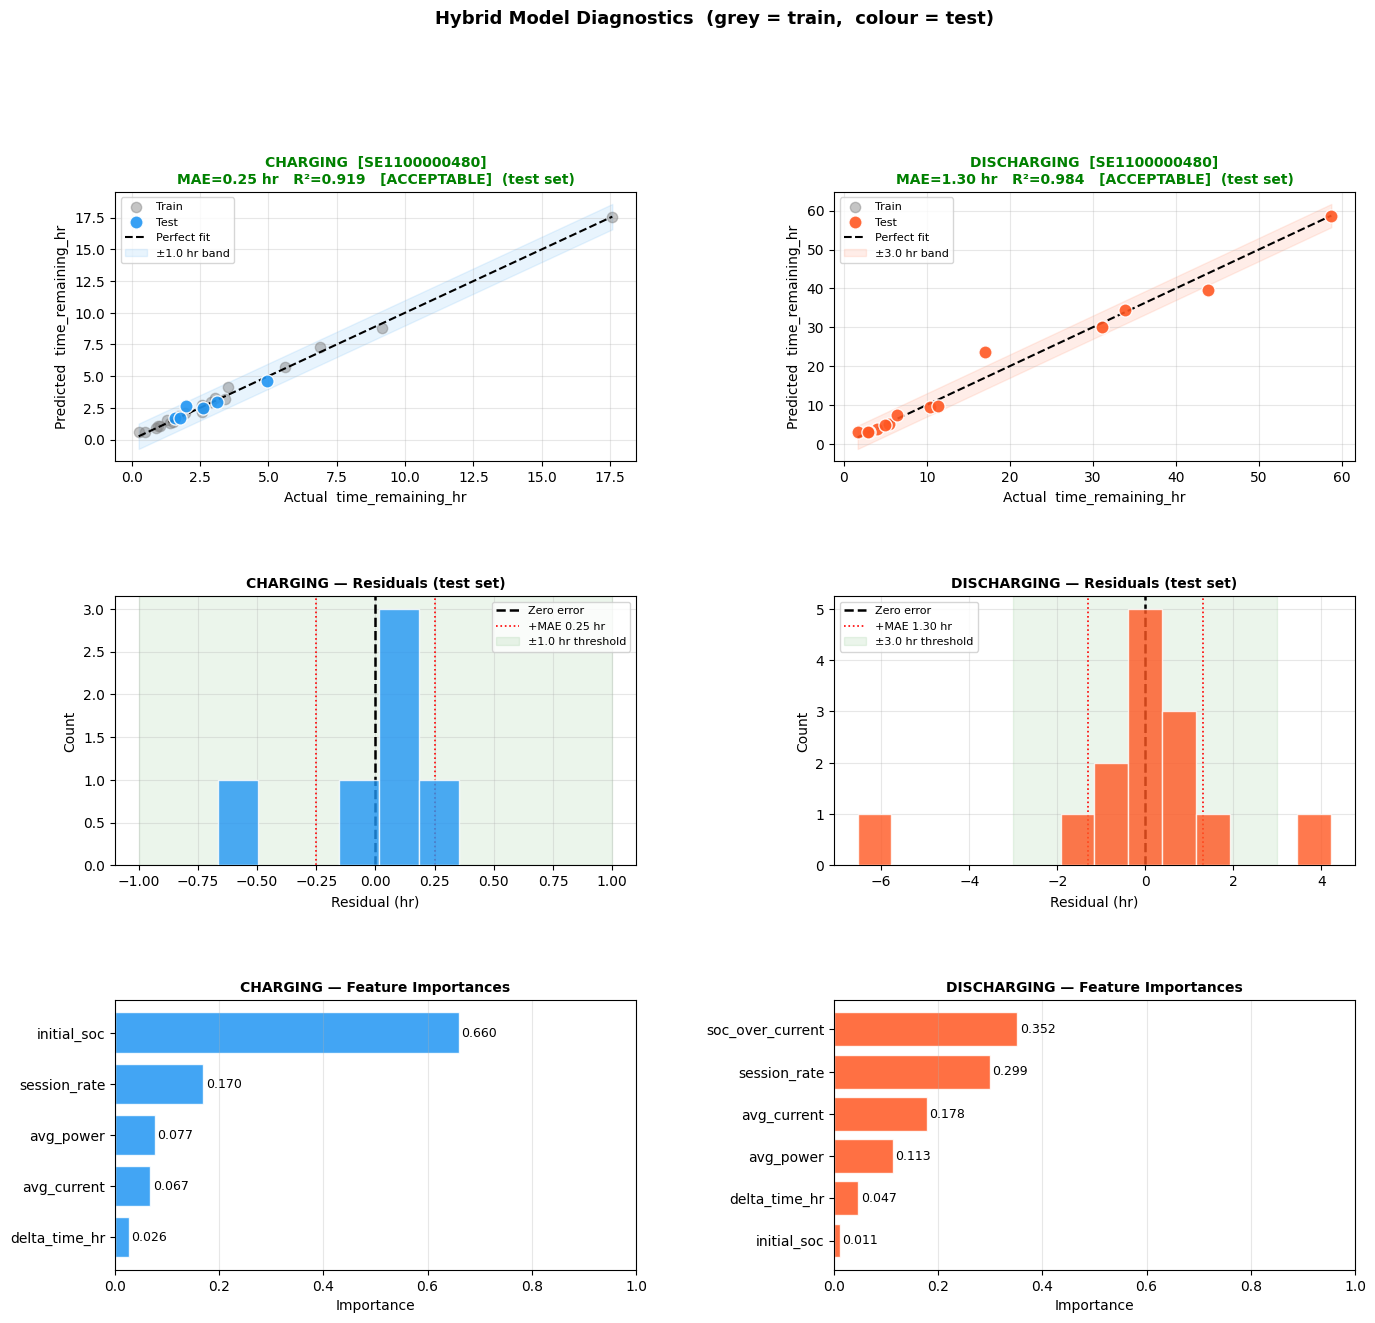


State            MAE (hr)    Limit       R²    Limit       Status
----------------------------------------------------------------
charging           0.2531      1.0   0.9195     0.80         PASS
discharging        1.3002      3.0   0.9836     0.80         PASS


In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Acceptability thresholds
MAE_THRESH = {'charging': 1.0, 'discharging': 3.0}
R2_THRESH  = 0.80
COLORS     = {'charging': '#2196F3', 'discharging': '#FF5722'}

# ── Draw using rf_eval_data saved by Cell 25 ──────────────────────────────────
# rf_eval_data contains:
#   y_true_all / y_pred_all  → ALL sessions (no cuts) — used for scatter + residuals
#   is_test                  → mask: True = held-out test row
#   mae / r2                 → computed on test set only — SAME number Cell 25 printed
entries = list(rf_eval_data.values())

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, len(entries), figure=fig, hspace=0.50, wspace=0.38)

for col, d in enumerate(entries):
    sname  = d['state_name']
    color  = COLORS[sname]
    yt     = d['y_true_all']
    yp     = d['y_pred_all']
    mask   = d['is_test']
    mae    = d['mae']       # test-set value — identical to Cell 25 printout
    r2     = d['r2']        # test-set value — identical to Cell 25 printout
    thr    = MAE_THRESH[sname]
    ok     = (mae <= thr) and (r2 >= R2_THRESH)
    label  = 'ACCEPTABLE' if ok else 'NEEDS WORK'
    lcol   = 'green'       if ok else 'red'

    print(f"[{d['batt_id']}][{sname}]  "
          f"n_total={len(yt)}  n_test={mask.sum()}  "
          f"MAE(test)={mae:.4f} hr  R²(test)={r2:.4f}")

    # ── Row 0: Actual vs Predicted — ALL sessions ─────────────────────
    ax0    = fig.add_subplot(gs[0, col])
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())

    # training points — grey, smaller
    ax0.scatter(yt[~mask], yp[~mask],
                color='grey', alpha=0.45, s=55, zorder=2, label='Train')
    # test points — full colour, larger
    ax0.scatter(yt[mask],  yp[mask],
                color=color, alpha=0.90, edgecolors='white', s=90,
                zorder=3, label='Test')

    ax0.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect fit')
    ax0.fill_between([lo, hi], [lo - thr, hi - thr], [lo + thr, hi + thr],
                     alpha=0.10, color=color, label=f'±{thr} hr band')
    ax0.set_title(
        f'{sname.upper()}  [{d["batt_id"]}]\n'
        f'MAE={mae:.2f} hr   R²={r2:.3f}   [{label}]  (test set)',
        fontsize=10, fontweight='bold', color=lcol)
    ax0.set_xlabel('Actual  time_remaining_hr')
    ax0.set_ylabel('Predicted  time_remaining_hr')
    ax0.legend(fontsize=8)
    ax0.grid(True, alpha=0.3)

    # ── Row 1: Residuals — test set only (matches the reported MAE/R²) ──
    resid_test = yt[mask] - yp[mask]
    ax1 = fig.add_subplot(gs[1, col])
    ax1.hist(resid_test, bins=max(5, len(resid_test)),
             color=color, alpha=0.80, edgecolor='white', zorder=3)
    ax1.axvline(0,    color='black', lw=1.8, ls='--', label='Zero error')
    ax1.axvline( mae, color='red',   lw=1.2, ls=':',  label=f'+MAE {mae:.2f} hr')
    ax1.axvline(-mae, color='red',   lw=1.2, ls=':')
    ax1.axvspan(-thr, thr, alpha=0.08, color='green', label=f'±{thr} hr threshold')
    ax1.set_title(f'{sname.upper()} — Residuals (test set)',
                  fontsize=10, fontweight='bold')
    ax1.set_xlabel('Residual (hr)')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # ── Row 2: Feature importances ────────────────────────────────────
    ax2   = fig.add_subplot(gs[2, col])
    fnames = [f.replace('session_avg_', 'avg_') for f in d['features']]
    imps   = d['importances']
    idx    = np.argsort(imps)
    bars   = ax2.barh([fnames[j] for j in idx], imps[idx],
                      color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, imps[idx]):
        ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)
    ax2.set_xlim(0, 1.0)
    ax2.set_title(f'{sname.upper()} — Feature Importances',
                  fontsize=10, fontweight='bold')
    ax2.set_xlabel('Importance')
    ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Hybrid Model Diagnostics  (grey = train,  colour = test)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('rf_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Acceptability summary ─────────────────────────────────────────────────────
print(f"\n{'State':<14} {'MAE (hr)':>10} {'Limit':>8} {'R²':>8} {'Limit':>8} {'Status':>12}")
print('-' * 64)
for d in entries:
    sname = d['state_name']
    ok    = (d['mae'] <= MAE_THRESH[sname]) and (d['r2'] >= R2_THRESH)
    print(f"{sname:<14} {d['mae']:>10.4f} {MAE_THRESH[sname]:>8.1f} "
          f"{d['r2']:>8.4f} {R2_THRESH:>8.2f} {'PASS' if ok else 'FAIL':>12}")

In [26]:
import joblib, os

# ── Load saved model for a specific battery ───────────────────────────────────
# Change battery_id to whichever battery you want to run inference on
battery_id = 'SE1100000480'
model_dir  = os.path.join(required_dir, 'models')   # same data dir used for training

fpath  = os.path.join(model_dir, f'{battery_id}_model.pkl')
bundle = joblib.load(fpath)

loaded_models = bundle['states']   # dict: state_val -> model/scaler/features
min_current_a = bundle['min_current_a']

print(f"Loaded : {fpath}")
for sv, m in loaded_models.items():
    print(f"  state = {m['state_name']}  |  features = {m['features']}")

Loaded : E:/ness_performance_evaluation/data/soh_test_4\models\SE1100000480_model.pkl
  state = charging  |  features = ['initial_soc', 'session_avg_current', 'session_avg_power', 'delta_time_hr', 'session_rate']
  state = discharging  |  features = ['initial_soc', 'session_avg_current', 'session_avg_power', 'soc_over_current', 'delta_time_hr', 'session_rate']


In [27]:
# ── Read new data — same pipeline as training ─────────────────────────────────
# Point required_dir to the folder that has the new parquet files
required_dir = 'E:/ness_performance_evaluation/data/soh_test_4'   # update as needed

new_summary_df = process_data(required_dir, things_board_ids)

print(f"Sessions loaded : {len(new_summary_df)}")
print(f"Columns         : {list(new_summary_df.columns)}")
display(new_summary_df.head())

Sessions loaded : 41
Columns         : ['id', 'session_id', 'state', 'start_time', 'end_time', 'start_soc', 'end_soc', 'delta_soc', 'delta_time_hr', 'time_remaining_hr', 'session_avg_current', 'session_avg_power', 'soc_over_current', 'session_rate', 'initial_soc']


,id,session_id,state,start_time,end_time,start_soc,end_soc,delta_soc,delta_time_hr,time_remaining_hr,session_avg_current,session_avg_power,soc_over_current,session_rate,initial_soc
0,SE1100000480,31,4,2025-05-08 15:30:24.435000+05:30,2025-05-08 15:55:05.203000+05:30,24.0,34.0,10.0,0.411324,3.126066,22.690620,1213.298799,1.057706,0.041132,24.0
1,SE1100000480,61,3,2025-05-08 16:19:27.467000+05:30,2025-05-08 17:00:06.644000+05:30,37.0,22.0,-15.0,0.677549,1.671288,20.181508,1048.227125,1.833362,0.045170,37.0
2,SE1100000480,71,3,2025-05-08 19:03:05.494000+05:30,2025-05-09 03:57:16.745000+05:30,23.0,11.0,-12.0,8.903125,17.064323,1.294202,67.006078,17.771563,0.741927,23.0
3,SE1100000480,74,4,2025-05-09 05:54:06.978000+05:30,2025-05-09 07:06:06.328000+05:30,8.0,24.0,16.0,1.199819,6.898962,11.734356,619.931422,0.681759,0.074989,8.0
4,SE1100000480,78,4,2025-05-09 07:07:01.464000+05:30,2025-05-09 08:19:56.124000+05:30,24.0,51.0,27.0,1.215183,3.420516,19.043707,1018.440348,1.260259,0.045007,24.0


In [28]:
import numpy as np
import pandas as pd

# ── Predict time_remaining_hr using loaded hybrid model ───────────────────────
all_results = []

for sv, bundle in loaded_models.items():

    feats   = bundle['features']
    model   = bundle['model']
    scaler  = bundle['scaler']
    thr     = bundle['physics_threshold']
    min_i   = min_current_a
    sname   = bundle['state_name']
    batt_id = battery_id

    # ── Filter — same cuts as training ────────────────────────────────────
    extra = ['session_id', 'time_remaining_hr'] if 'time_remaining_hr' in new_summary_df.columns else ['session_id']
    df = (
        new_summary_df[
            (new_summary_df['id'] == batt_id) &
            (new_summary_df['state'] == sv)
        ][feats + extra]
        .dropna(subset=feats)
        .reset_index(drop=True)
    )
    df = df[df['session_avg_current'] >= min_i].reset_index(drop=True)

    if len(df) == 0:
        print(f"[{batt_id}][{sname}]  No sessions found")
        continue

    # ── RF prediction ──────────────────────────────────────────────────────
    X_sc    = scaler.transform(df[feats])
    rf_pred = np.expm1(model.predict(X_sc))

    # ── Session-rate formula for extreme sessions ──────────────────────────
    soc  = df['initial_soc'].values
    rate = df['session_rate'].values

    if sv == 4:   # charging
        formula_pred = (100.0 - soc) * rate
    else:          # discharging
        formula_pred = soc * rate

    extreme  = formula_pred > thr
    nan_mask = np.isnan(rate)

    if nan_mask.any():
        meta     = bat_meta_data_dict.get(batt_id, {})
        Q_nom_Ah = meta.get('reference_capacity', 120000) / 1000.0
        safe_I   = np.maximum(df['session_avg_current'].values, 0.1)
        if sv == 3:
            phys = (soc / 100.0) * Q_nom_Ah / safe_I
        else:
            phys = ((100.0 - soc) / 100.0) * Q_nom_Ah / safe_I
        formula_pred = np.where(nan_mask, phys, formula_pred)
        extreme = extreme | nan_mask

    final_pred = np.where(extreme, formula_pred, rf_pred)

    # ── Build result table ─────────────────────────────────────────────────
    result = df[['session_id', 'initial_soc', 'session_avg_current',
                 'session_avg_power', 'session_rate']].copy()
    result['predicted_time_remaining_hr'] = np.round(final_pred, 2)
    result['method'] = np.where(extreme, 'formula', 'RF')
    if 'time_remaining_hr' in df.columns:
        result['actual_time_remaining_hr'] = df['time_remaining_hr'].values
    result.insert(0, 'state',      sname)
    result.insert(0, 'battery_id', batt_id)

    print(f"\n[{batt_id}][{sname}]  sessions = {len(result)}")
    display(result)
    all_results.append(result)

if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    print(f"\nTotal predictions: {len(final_df)}")
else:
    print("No predictions — check battery_id and required_dir")


[SE1100000480][charging]  sessions = 27


,battery_id,state,session_id,initial_soc,session_avg_current,session_avg_power,session_rate,predicted_time_remaining_hr,method,actual_time_remaining_hr
0,SE1100000480,charging,31,24.0,22.690620,1213.298799,0.041132,2.96,RF,3.126066
1,SE1100000480,charging,74,8.0,11.734356,619.931422,0.074989,7.33,RF,6.898962
2,SE1100000480,charging,78,24.0,19.043707,1018.440348,0.045007,3.20,RF,3.420516
3,SE1100000480,charging,371,95.0,16.680333,896.217347,0.050853,0.62,RF,0.254263
4,SE1100000480,charging,680,0.0,5.084603,261.858359,0.175789,17.58,formula,17.578875
5,SE1100000480,charging,684,4.0,15.266055,800.607982,0.058540,5.75,RF,5.619809
6,SE1100000480,charging,686,24.0,22.341944,1187.085757,0.038189,2.99,RF,2.902371
7,SE1100000480,charging,688,32.0,24.079826,1286.324932,0.037808,2.71,RF,2.570913
8,SE1100000480,charging,694,47.0,24.370176,1305.051760,0.037240,2.64,RF,1.973726
9,SE1100000480,charging,753,46.0,17.524523,930.053105,0.048270,2.47,RF,2.606576



[SE1100000480][discharging]  sessions = 14


,battery_id,state,session_id,initial_soc,session_avg_current,session_avg_power,session_rate,predicted_time_remaining_hr,method,actual_time_remaining_hr
0,SE1100000480,discharging,61,37.0,20.181508,1048.227125,0.045170,2.97,RF,1.671288
1,SE1100000480,discharging,71,23.0,1.294202,67.006078,0.741927,23.60,RF,17.064323
2,SE1100000480,discharging,675,97.0,27.409853,1419.466402,0.040749,3.83,RF,3.952648
3,SE1100000480,discharging,701,87.0,25.669280,1342.785846,0.035264,3.05,RF,3.067966
4,SE1100000480,discharging,703,83.0,13.616881,712.522155,0.066048,5.04,RF,5.481956
5,SE1100000480,discharging,751,66.0,20.152205,1049.448594,0.044032,2.94,RF,2.906085
6,SE1100000480,discharging,781,98.0,8.423451,442.330312,0.106522,9.36,RF,10.439166
7,SE1100000480,discharging,782,56.0,9.110365,469.815284,0.114011,7.38,RF,6.384636
8,SE1100000480,discharging,2238,100.0,16.516207,871.308467,0.049152,4.80,RF,4.915172
9,SE1100000480,discharging,2250,93.0,9.307153,484.042892,0.121797,9.65,RF,11.327144



Total predictions: 41
